<a href="https://colab.research.google.com/github/theezen/ADALL_github/blob/main/Copy_of_ADALL_Week5_Model_Eval_Practical_Test_Revision_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADALL Practical Test Revision: Regression Workflow

## Single-session version

This notebook is designed for **one revision session**.

The main route is short. Read the optional sections only after you finish the main route.

### Session target
By the end of this session, you should be able to:

1. explain why this is a **regression** task,
2. create the target `num_failed_subjects`,
3. avoid leakage from `G1`, `G2`, and `G3`,
4. create a dataset profile for LLM review,
5. train models using a pipeline,
6. compare results using CV and holdout MAE,
7. write a short judgement-based answer.

### Suggested timing

| Part | Time |
|---|---:|
| Admin and test reminder | 10 to 15 min |
| Main route in this notebook | 75 to 90 min |
| Recap and Q&A | 15 to 20 min |
| Optional practice | After class |

<div style="background-color:#eaf4ff; border-left:6px solid #2b7bbb; padding:12px;">
<strong>Main idea:</strong> The practical test is not mainly about writing many new lines of code. It is about knowing what the code is doing, running the right block, checking the result, and explaining your decision clearly.
</div>


## What the previous lecturer focused on

The transcript suggests that this revision should focus on the following points:

| Focus area | What students should pay attention to |
|---|---|
| Regression only | The practical test focuses on predicting a number, not classification. |
| Read instructions carefully | If a cell says “run only”, do not edit it unnecessarily. |
| Dataset profile and payload text | You should know how to summarise the dataset for LLM-assisted review. |
| Leakage | `G1`, `G2`, and `G3` directly define the target, so they must not be used as predictors. |
| Train/test split | Keep the test set for final checking. Use a fixed `random_state`. |
| Pipeline | Use the same preprocessing and modelling structure fairly. |
| Model comparison | Choose based on evidence, not because a model sounds more advanced. |

<div style="background-color:#fff8e6; border-left:6px solid #d69b00; padding:12px;">
<strong>Revision stance:</strong> You are practising judgement. Do not accept every LLM recommendation automatically. Check whether the recommendation makes sense for the task.
</div>


## Step 0. Setup

Run this cell first.

Do not edit the imports unless you get a clear library error.


In [ ]:
# Core libraries
import os
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Modelling
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor


### What to check after Step 0

You should see no error.

If there is an error, it is usually because a library is not installed in the runtime. In Colab, install the missing library, restart the runtime if needed, then run the setup again.


## Step 1. Load the dataset and do quick checks

The practical test may provide the loading code for you.

When the instruction says **run the cell**, just run it first. Do not rewrite the loading code unless the question asks you to.

In this revision notebook, we use the student performance dataset.


In [ ]:
# Load data from KaggleHub
# In the actual practical test, the dataset path/code may be provided to you.

import kagglehub

path = kagglehub.dataset_download("devansodariya/student-performance-data")
print("Downloaded to:", path)
print("Files:", os.listdir(path))

df = pd.read_csv(os.path.join(path, "student_data.csv"))
df.head()


Using Colab cache for faster access to the 'student-performance-data' dataset.
Downloaded to: /kaggle/input/student-performance-data
Files: ['student_data.csv']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Quick checks
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData info:")
df.info()


Shape: (395, 33)

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11

### What to check after Step 1

Check these before moving on:

1. Does the dataset load correctly?
2. How many rows and columns are there?
3. Are `G1`, `G2`, and `G3` present?
4. Are there missing values?
5. Which columns are numeric and which are categorical?

Short answer format:

```text
The dataset has ___395 rows and ___33 columns. It contains a mix of numeric and categorical columns. The grade columns are G1, G2 and G3.
```


## Step 2. Create a dataset profile for LLM review

A dataset profile is a text summary of the dataset.

You use it so the LLM does not need the full dataset. It can review the structure, missing values, data types, correlations, and possible risks.

### What the payload should include

- dataset shape,
- column data types,
- numeric summary,
- categorical summary,
- missing values,
- unique value counts,
- simple correlation information,
- possible leakage clues.

<div style="background-color:#fff0f0; border-left:6px solid #d93636; padding:12px;">
<strong>Important:</strong> The LLM recommendation is not automatically correct. You still need to decide whether each recommendation is sensible.
</div>


In [ ]:
from io import StringIO

buffer = StringIO()

buffer.write("=== SHAPE ===\n")
buffer.write(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n\n")

buffer.write("=== DTYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

buffer.write("=== NUMERIC DESCRIBE ===\n")
buffer.write(df.describe().to_string())
buffer.write("\n\n")

buffer.write("=== CATEGORICAL DESCRIBE ===\n")
cat_cols = df.select_dtypes(include="object").columns.tolist()
if cat_cols:
    buffer.write(df[cat_cols].describe().to_string())
else:
    buffer.write("No categorical columns")
buffer.write("\n\n")

buffer.write("=== NULL SUMMARY ===\n")
null_summary = df.isna().sum().to_frame("null_count")
null_summary["null_pct"] = null_summary["null_count"] / len(df)
buffer.write(null_summary.to_string())
buffer.write("\n\n")

buffer.write("=== UNIQUE VALUES PER COLUMN ===\n")
buffer.write(df.nunique().to_frame("unique_count").to_string())
buffer.write("\n\n")

buffer.write("=== CORRELATIONS: NUMERIC ONLY ===\n")
buffer.write(df.corr(numeric_only=True).round(3).to_string())
buffer.write("\n\n")

buffer.write("=== POSSIBLE UNIQUE-ID COLUMNS ===\n")
unique_id_cols = df.columns[df.nunique() == len(df)].tolist()
buffer.write(str(unique_id_cols))
buffer.write("\n")

payload_text = buffer.getvalue()
print(payload_text)


=== SHAPE ===
Rows: 395, Columns: 33

=== DTYPES ===
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64

=== NUMERIC DESCRIBE ===
              age        Medu        Fedu  traveltime   studytime    failures      famrel    freetime       goout        Dalc        Walc      health    absences          G1          G2          G3
count  395.000000  395.000000 

### What to check after Step 2

Your payload should be readable.

Check that it contains enough information for a reviewer to answer:

1. What is the dataset size?
2. What are the main column types?
3. Are there missing values?
4. Are there possible leakage columns?
5. Are `G1`, `G2`, and `G3` strongly related to the target you plan to create?

The payload is readable because it summarises the dataset using clear sections for shape, data types, numeric and categorical summaries, missing values, unique counts, correlations and possible ID columns.

The dataset size is shown under the SHAPE section as the number of rows and columns. Each row represents one student, while the columns contain student characteristics and grades.

The dataset contains a mixture of numeric and categorical columns. Numeric columns include grades, age, absences and other measurements. Categorical columns include labels such as school, sex and Yes/No responses.

Missing values should be checked using the NULL SUMMARY section. If all null counts are zero, there are no detected missing values. If any count is above zero, those columns need further investigation.

G1, G2 and G3 are leakage columns because the target num_failed_subjects is calculated directly from them. Keeping these columns would give the model the information needed to calculate the answer and would make the evaluation unrealistic.

G1, G2 and G3 are therefore strongly related to the target. In fact, they directly define it because the target counts how many of the three grades are below 10.

## Step 3. Ask the LLM a small, focused question

Do not ask the LLM to solve everything at once.

Start with a small review question:

> “Based on this dataset profile and the target definition, what data risks should I check before modelling?”

The aim is to get a review, not to blindly follow instructions.


In [ ]:
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

# Only use this section if your tutor has asked you to call the API from Colab.
# You must first save OPENAI_API_KEY in Colab Secrets.

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

OpenAI client is ready.


In [ ]:
llm_prompt = f"""
You are helping me review a regression dataset for a practical test revision.

Task:
I want to predict the number of failed subjects.
A subject is failed when its grade is below 10.
The grade columns are G1, G2 and G3.

Dataset profile:
{payload_text}

Please answer in three sections:
1. Data quality issues to check before modelling.
2. Columns that may cause leakage, with reasons.
3. Which recommendations need human judgement before applying.

Keep the answer concise. Do not write modelling code yet.
"""

print(llm_prompt)



You are helping me review a regression dataset for a practical test revision.

Task:
I want to predict the number of failed subjects.
A subject is failed when its grade is below 10.
The grade columns are G1, G2 and G3.

Dataset profile:
=== SHAPE ===
Rows: 395, Columns: 33

=== DTYPES ===
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64

=== NUMERIC DES

### Optional: use the OpenAI API

Run this only if your Colab secret `OPENAI_API_KEY` is already set.

Otherwise, copy the printed prompt above and paste it into the approved LLM tool.


In [ ]:
if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=llm_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')



LLM response:
## 1) Data quality issues to check before modelling
- **Target definition consistency**: You want *failed subjects* when **grade < 10** (from **G1, G2, G3**). Confirm how you will convert grades into the regression target:
  - failure if **any** of {G1,G2,G3} < 10 vs **all** vs e.g. using the **average/min**.
- **Potential target redundancy / mismatch**:
  - There is already a numeric column **`failures`** (count). Verify what it represents in this dataset (e.g., number of past school failures) and whether it is the same concept as “grade < 10”.
- **Grade scaling/validity**:
  - Check that **G1/G2/G3** are on the expected scale (they run 0–19/20 range in stats; min is 0). Ensure **0 values are real** (not missing/placeholder).
- **Outliers / range issues**:
  - **`absences`** has a max of **75**—validate whether this is plausible or a data entry issue.
  - **`studytime`, `traveltime`, `health`, etc.** are discretized integers—ensure there aren’t unexpected category codes

### Decision point after LLM review

Write a short judgement note:

```text
I agree with ___ because ___.
I disagree with ___ because ___.
I will not use G1, G2, and G3 as predictors because they directly define the target.
```

This is the key learning point. The LLM can suggest, but you must judge.

I agree with checking grade scales, unusual values, categorical consistency, hidden missing values, and target distribution because these checks improve data quality before modelling.

I disagree that the target definition is unclear because num_failed_subjects is already defined as the count of G1, G2, and G3 values below 10.

I will not use G1, G2, and G3 as predictors because they directly define the target.

I will investigate failures, but I will not remove it automatically because correlation alone does not prove leakage.

I will verify all LLM recommendations using Python evidence and human judgement before applying them.


## Step 4. Create the target: number of failed subjects

This is the main target engineering step.

A subject is counted as failed when the grade is **less than 10**.

```text
G1 < 10 means failed G1
G2 < 10 means failed G2
G3 < 10 means failed G3
```

The target is the count of failed subjects across `G1`, `G2`, and `G3`.

Although the target values are usually 0, 1, 2, and 3, this is still treated as **regression** here because you are predicting a number.

### Common mistakes

| Mistake | Why it matters |
|---|---|
| Using `<= 10` instead of `< 10` | It changes the target definition. |
| Forgetting to check the target range | The target should normally be 0 to 3. |
| Using `G1`, `G2`, `G3` later as predictors | This causes leakage. |


In [ ]:
grade_cols = ["G1", "G2", "G3"]

# Count how many of G1, G2, G3 are below 10 for each student
df["num_failed_subjects"] = (df[grade_cols] < 10).sum(axis=1)

# Sanity check
print(df[grade_cols + ["num_failed_subjects"]].head())
print("\nTarget value counts:")
print(df["num_failed_subjects"].value_counts().sort_index())
print("\nTarget proportions:")
print(df["num_failed_subjects"].value_counts(normalize=True).sort_index())


   G1  G2  G3  num_failed_subjects
0   5   6   6                    3
1   5   5   6                    3
2   7   8  10                    2
3  15  14  15                    0
4   6  10  10                    1

Target value counts:
num_failed_subjects
0    221
1     30
2     44
3    100
Name: count, dtype: int64

Target proportions:
num_failed_subjects
0    0.559494
1    0.075949
2    0.111392
3    0.253165
Name: proportion, dtype: float64


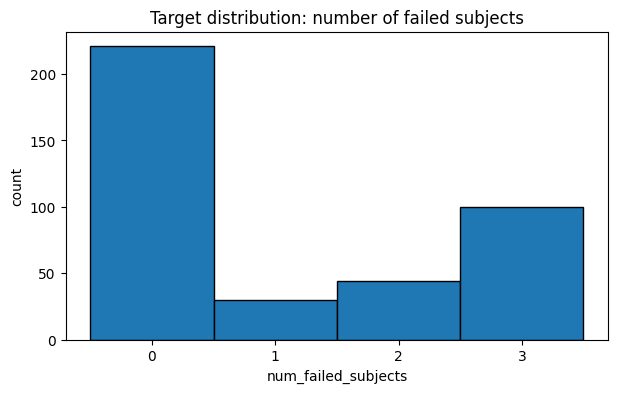

In [ ]:
# Visual check of target distribution
plt.figure(figsize=(7, 4))
plt.hist(df["num_failed_subjects"], bins=[-0.5, 0.5, 1.5, 2.5, 3.5], edgecolor="black")
plt.xticks([0, 1, 2, 3])
plt.title("Target distribution: number of failed subjects")
plt.xlabel("num_failed_subjects")
plt.ylabel("count")
plt.show()


### What to check after Step 4

Check:

1. Are the target values only 0, 1, 2, and 3?
2. Is the target imbalanced?
3. Are there very few cases for any target value?

Short answer format:

```text
The target ranges from ___ to ___. Most students have __ failed subjects. This matters because rare target values may be harder to predict.
```

The target ranges from 0 to 3. Most students have 0 failed subjects, while 1 failed subject is the rarest value. The distribution is imbalanced, so rare target values may be harder for the model to predict accurately.


## Step 5. Define X and y, then remove leakage columns

This is a very important test point.

`G1`, `G2`, and `G3` are used to calculate `num_failed_subjects`.

If you include them as predictors, the model is indirectly given the answer.

That is leakage.

### Simple example

If I already know all three subject marks, I can calculate the number of failed subjects directly.

So the model does not need to learn from behaviour, background, or other features. It is just using the answer source.

<div style="background-color:#fff0f0; border-left:6px solid #d93636; padding:12px;">
<strong>Rule for this task:</strong> Drop <code>G1</code>, <code>G2</code>, and <code>G3</code> from X after creating the target.
</div>


In [ ]:
target_col = "num_failed_subjects"
leakage_cols = ["G1", "G2", "G3"]

X = df.drop(columns=[target_col] + leakage_cols)
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Columns removed for leakage:", leakage_cols)


X shape: (395, 30)
y shape: (395,)
Columns removed for leakage: ['G1', 'G2', 'G3']


### Decision point after Step 5

Write this in your answer if asked about leakage:

```text
I removed G1, G2 and G3 because the target is calculated from these columns. Keeping them would leak the answer into the model and make the evaluation unrealistic.
```


## Step 6. Train/test split

The test set is used only for final checking.

For normal regression, we usually do not stratify.

However, this target is a small integer count: 0, 1, 2, 3. It behaves partly like groups. In this revision example, we use `stratify=y` so the train and test sets keep similar target proportions.

### Caveat
If the target has rare values, stratified splitting may fail or create very small groups. Always check the value counts.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTrain target proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target proportions:")
print(y_test.value_counts(normalize=True).sort_index())


Train shape: (355, 30) (355,)
Test shape: (40, 30) (40,)

Train target proportions:
num_failed_subjects
0    0.560563
1    0.076056
2    0.109859
3    0.253521
Name: proportion, dtype: float64

Test target proportions:
num_failed_subjects
0    0.550
1    0.075
2    0.125
3    0.250
Name: proportion, dtype: float64


### What to check after Step 6

Check that the train and test target proportions are reasonably similar.

Short answer format:

```text
The train and test sets have similar target proportions, so the holdout test set is a reasonable final check.
```


## Step 7. Build the preprocessing pipeline

The dataset has both numeric and categorical columns.

A pipeline helps you apply the same preparation steps during training and prediction.

### What happens here

| Column type | What we do |
|---|---|
| Numeric columns | Pass through as they are |
| Categorical columns | One-hot encode them |

### Why this matters

A pipeline reduces mistakes because the preprocessing is fitted on the training data and then applied consistently to validation and test data.

This avoids common errors such as preparing train and test data differently.


In [ ]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['age', 'Medu', 'Fedu', 'traveltime',
                                  'studytime', 'failures', 'famrel', 'freetime',
                                  'goout', 'Dalc', 'Walc', 'health',
                                  'absences']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['school', 'sex', 'address', 'famsize',
                                  'Pstatus', 'Mjob', 'Fjob', 'reason',
                                  'guardian', 'schoolsup', 'famsup', 'paid',
                                  'activities', 'nursery', 'higher', 'internet',
                                  'romantic'])])

### What to check after Step 7

Check:

1. Did the code correctly separate numeric and categorical columns?
2. Are categorical columns being encoded?
3. Is the preprocessing inside the pipeline later?

Short answer format:

```text
The pipeline uses a ColumnTransformer so numeric and categorical columns are handled consistently before modelling.
```


## Step 8. Train and compare models using CV

We compare two tree-based models:

- Random Forest
- XGBoost

The main point is not to memorise the model code.

The main point is to compare fairly using the same:

1. train/test split,
2. preprocessing,
3. CV method,
4. metric.

### CV reminder

Cross-validation repeats model checking on different splits of the training data.

Here we use `ShuffleSplit`:

```text
Round 1: use part of training data for validation, train on the rest
Round 2: reshuffle, use another validation part, train on the rest
...
Average the validation scores
```

We also record train MAE so we can check overfitting.


In [ ]:
# Keep this small enough for a single revision session.
# The goal is model comparison, not exhaustive tuning.

cv = ShuffleSplit(n_splits=5, test_size=0.20, random_state=42)

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])

    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        return_train_score=True,
        n_jobs=-1
    )

    train_mae = -cv_out["train_score"]
    val_mae = -cv_out["test_score"]

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    holdout_mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "model": name,
        "cv_train_mae_mean": train_mae.mean(),
        "cv_train_mae_std": train_mae.std(),
        "cv_val_mae_mean": val_mae.mean(),
        "cv_val_mae_std": val_mae.std(),
        "train_val_gap": val_mae.mean() - train_mae.mean(),
        "holdout_mae": holdout_mae,
        "holdout_rmse": rmse,
        "holdout_r2": r2
    })

    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("cv_val_mae_mean")
results_df


,model,cv_train_mae_mean,cv_train_mae_std,cv_val_mae_mean,cv_val_mae_std,train_val_gap,holdout_mae,holdout_rmse,holdout_r2
1,XGBoost,0.505079,0.017404,1.009434,0.090180,0.504355,1.066606,1.232403,0.090188
0,Random Forest,0.522767,0.026801,1.033943,0.083931,0.511176,0.954804,1.087251,0.291882


### What to check after Step 8

Check the result table in this order:

1. Which model has lower **CV validation MAE**? XG Boost
2. Is the train MAE much lower than the validation MAE? 0.504355/0.511176	 acceptable
3. Does the holdout MAE support the CV result? Yes
4. Is the improvement meaningful, or only tiny? not much very tiny

Short answer format:

```text
I would choose ___XG_boost because it has lower validation MAE, the train-validation gap is acceptable, and the holdout MAE supports the CV result.
```
Correct review
Lower CV validation MAE: XGBoost
XGBoost: 1.0094
Random Forest: 1.0339
Difference: only about 0.0245, so the improvement is very small.

Train–validation gap: Both models show a sizeable gap.

XGBoost: 0.5044
Random Forest: 0.5112

The validation MAE is almost twice the training MAE for both models, suggesting possible overfitting. The gap should not simply be called acceptable without caution.

Holdout MAE: Random Forest is better.
Random Forest: 0.9548
XGBoost: 1.0666
Other holdout metrics also favour Random Forest:
Lower RMSE: 1.0873 versus 1.2324
Higher R²: 0.2919 versus 0.0902

Do not choose a model only because it sounds more advanced.

XGBoost has the lower cross-validation validation MAE, but the improvement over Random Forest is very small.

Both models have a noticeable train-validation gap, which suggests possible overfitting.

The holdout results do not support XGBoost. Random Forest has the lower holdout MAE and RMSE, and the higher holdout R².

I would therefore choose Random Forest because it performs better on the unseen holdout data, even though XGBoost has a slightly lower cross-validation validation MAE.


## Step 9. Plot actual vs predicted values

This plot helps you see whether the model is roughly following the true target values.

Because the target is 0 to 3, predictions may be non-integers.

That is normal for regression.

Only round predictions if the question asks for integer outputs.


Best model based on CV validation MAE: XGBoost


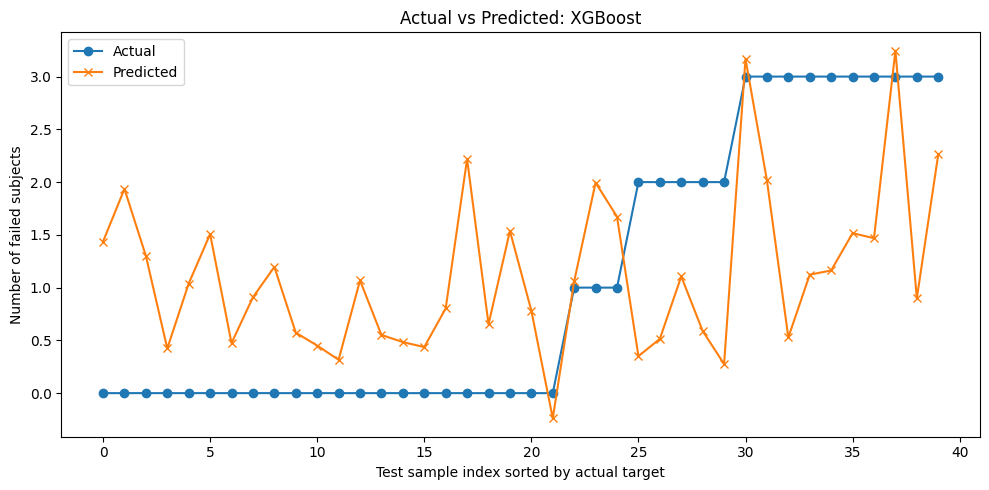

In [ ]:
# Choose the model with the best CV validation MAE
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

print("Best model based on CV validation MAE:", best_model_name)

y_pred_test = best_model.predict(X_test)

# Sort by true target so the pattern is easier to see
order = np.argsort(y_test.to_numpy())
y_true_sorted = y_test.to_numpy()[order]
y_pred_sorted = y_pred_test[order]

plt.figure(figsize=(10, 5))
plt.plot(y_true_sorted, label="Actual", marker="o")
plt.plot(y_pred_sorted, label="Predicted", marker="x")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.xlabel("Test sample index sorted by actual target")
plt.ylabel("Number of failed subjects")
plt.legend()
plt.tight_layout()
plt.show()


### What to check after Step 9

Look for:

1. Does the predicted line roughly follow the actual line? it tries to follow and fairly close.
2. Does the model over-predict students with 0 failed subjects? Yes, it's over predict slightly.
3. Does the model under-predict students with 2 or 3 failed subjects? yes, it has under predicted  
4. Are the largest errors concentrated in rare target values? Not enough data to analyse

Short answer format:

```text
The model generally follows the actual values, but it struggles more with ___1 because ___error gap is quiet big.
```
The model follows some of the actual pattern, but the predictions are not consistently close.

It often over-predicts students with 0 failed subjects and under-predicts students with 2 or 3 failed subjects.

The model appears to struggle most with the extreme target values, especially 0 and 3, because the prediction gaps are sometimes large.

From the graph alone, I cannot confirm whether the largest errors are caused by rare target values. I would need the error values grouped by each target category.

L-Style:
The model generally captures some of the pattern, but it struggles more with target values 0 and 3 because the prediction gaps are often large.

It tends to over-predict students with 0 failed subjects and under-predict students with 2 or 3 failed subjects.

## Step 10. Final judgement answer

Use this structure for a short written response.

```text
I treated this as a regression task because the target is a numeric count: number of failed subjects.

I created the target by counting how many of G1, G2, and G3 are below 10.

I removed G1, G2, and G3 from the predictors because they directly define the target and would cause leakage.

I used a pipeline so that preprocessing and modelling are applied consistently.

Based on the CV validation MAE, train-validation gap, and holdout MAE, I would choose ___ because ___.
```

<div style="background-color:#eaf4ff; border-left:6px solid #2b7bbb; padding:12px;">
<strong>Recap:</strong> Good practical-test answers are short, evidence-based, and clear. You do not need to explain every line of code.
</div>


# Optional Reading

Read this only after the main route.

## Why this target is a slight edge case

The target `num_failed_subjects` has values like 0, 1, 2, and 3.

That can feel like classification because the values look like categories.

But in this notebook, we treat it as regression because the target is a count.

### Standard interpretation

| Situation | Usually use |
|---|---|
| Predict a continuous number, such as price | Regression |
| Predict a count, such as number of failed subjects | Often regression, sometimes count models |
| Predict a category, such as pass/fail | Classification |

### Edge case

If the task changes to “predict whether a student failed at least one subject”, then the target becomes:

```text
0 = no failed subject
1 = failed at least one subject
```

That becomes classification.

So the method depends on how the target is defined.


# Optional Reading: CV and train/test split

## Train/test split

A train/test split holds back some data for final checking.

The model should not use the test set during training or model selection.

## Cross-validation

CV checks the model several times using different validation splits inside the training data.

For ShuffleSplit, each round reshuffles the training data and creates a new validation split.

```text
Round 1: train on most of the training data, validate on a held-out part
Round 2: reshuffle, train again, validate on another held-out part
Round 3: reshuffle, train again, validate on another held-out part
```

This reduces the chance that your result is due to one lucky split.

## Stratification caveat

For normal regression, stratification is not usually used.

Here, the target is a small integer count. Using `stratify=y` helps keep the 0, 1, 2, 3 proportions similar between train and test.

If a target value is very rare, stratification may fail or give unstable results.


# Additional Practice

Do these after class or during revision.

## Practice 1: Explain leakage

Write a 3-line answer explaining why `G1`, `G2`, and `G3` should be removed.

## Practice 2: Improve one modelling choice

Try only one improvement:

- change Random Forest `max_depth`, or
- change XGBoost `max_depth`, or
- change XGBoost `learning_rate`.

Then compare the new result with the original result.

Do not tune many things at once.

## Practice 3: Ask the LLM to review your answer

Use this prompt:

```text
Here is my practical-test answer. Check if it is clear, evidence-based, and free from leakage mistakes. Do not rewrite everything. Point out only the top three improvements.
```

Paste your own answer below that prompt.


In [2]:
# Default method: copy the prompt into the chatbot manually.
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

# Only use this section if your tutor has asked you to call the API from Colab.
# You must first save OPENAI_API_KEY in Colab Secrets.

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

# This cell prepares the notebook to use the OpenAI API, if needed.
# RUN_API_CELLS controls whether the notebook uses the API or manual chatbot mode.
# If RUN_API_CELLS is True, the notebook will try to connect to OpenAI using an API key.
# If RUN_API_CELLS is False, students can copy the prompt and paste it into ChatGPT manually.
# OPENAI_MODEL stores the model name that will be used later when sending prompts.
# client starts as None first, then becomes an OpenAI client after the API key is loaded.
# userdata.get('OPENAI_API_KEY') reads the API key saved in Colab Secrets.
# OpenAI(api_key=api_key) creates the connection object used to call the API.

OpenAI client is ready.


In [3]:
from openai import OpenAI

client = OpenAI(api_key=api_key)

my_question = """
Which model should I choose, and why?
"""

evidence = """
XGBoost:
CV validation MAE = 1.0094
Holdout MAE = 1.0666

Random Forest:
CV validation MAE = 1.0339
Holdout MAE = 0.9548
"""

my_answer = """
I am not sure which model to choose.
"""

prompt = f"""
I may have no answer or an incorrect answer.

Use only the notebook evidence below to answer the question correctly.
Do not invent information.

Question:
{my_question}

Evidence:
{evidence}

My draft answer, if any:
{my_answer}

Provide:
1. Verdict on my draft
2. Correct reasoning
3. One short answer in this style:
   "I agree with ___ because ___."
   "I disagree with ___ because ___."
"""

response = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt
)

print(response.output_text)

1. **Verdict on your draft:**  
Your draft (“I am not sure which model to choose.”) is **partly incorrect**—based on the provided evidence, there is a clearer choice.

2. **Correct reasoning:**  
Compare **Holdout MAE** (the most direct test of generalization):  
- **XGBoost Holdout MAE = 1.0666**  
- **Random Forest Holdout MAE = 0.9548**  

Since **lower MAE is better**, **Random Forest** performs better on the holdout set. Even though XGBoost has a slightly better CV MAE, the holdout results indicate better real-world/generalization performance for Random Forest.

3. **One short answer in this style:**  
**“I disagree with your draft because Random Forest has the lower holdout MAE (0.9548 vs 1.0666), so it generalizes better based on the provided evidence.”**
